In [1]:
import os
from google.colab import drive
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
!pip install catboost
!pip install xgboost
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.6 MB/s eta 0:00:00


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prasad22/healthcare-dataset")

print("Path to dataset files:", path)

100%|██████████| 2.91M/2.91M [00:00<00:00, 55.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/prasad22/healthcare-dataset/versions/2


In [5]:
dataset_folder_path = '/content/drive/MyDrive/Datasets'
healthcare_folder_path = os.path.join(dataset_folder_path, 'healthcare_prediction_dataset')
os.makedirs(healthcare_folder_path, exist_ok=True)

for file in os.listdir(path):
    shutil.move(os.path.join(path, file),os.path.join(healthcare_folder_path, file))

print(f'dataset downloaded to this path {healthcare_folder_path}')

dataset downloaded to this path /content/drive/MyDrive/Datasets/healthcare_prediction_dataset


In [11]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Import classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/healthcare_prediction_dataset/healthcare_dataset.csv')

In [4]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [6]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [7]:
df.isna()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
55496,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
55497,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
55498,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [12]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days
df.drop(columns=['Name', 'Doctor', 'Hospital', 'Room Number'], inplace=True)

# Separate features (X) and target (y)
X = df.drop(columns=['Test Results'])
y = df['Test Results']

# Categorical and numerical columns
categorical_cols = ['Gender', 'Blood Type', 'Medical Condition', 'Admission Type', 'Insurance Provider', 'Medication']
numerical_cols = ['Age', 'Billing Amount']

# Create the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Transform the features
X_transformed = preprocessor.fit_transform(X)


Training Logistic Regression...
Classification Report for Logistic Regression:
              precision    recall  f1-score   support

    Abnormal       0.35      0.44      0.39      3754
Inconclusive       0.33      0.27      0.30      3617
      Normal       0.34      0.32      0.33      3729

    accuracy                           0.34     11100
   macro avg       0.34      0.34      0.34     11100
weighted avg       0.34      0.34      0.34     11100

ROC-AUC Score: 0.5042646300024313



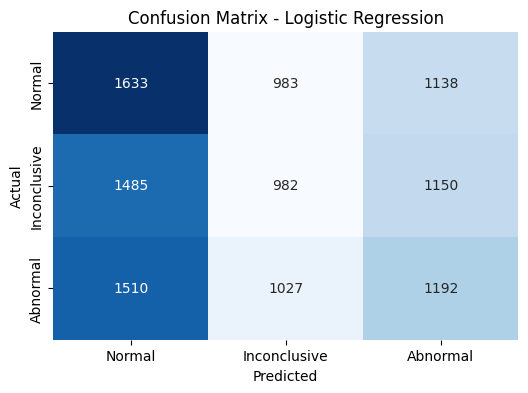

Training Decision Tree...
Classification Report for Decision Tree:
              precision    recall  f1-score   support

    Abnormal       0.41      0.41      0.41      3754
Inconclusive       0.41      0.41      0.41      3617
      Normal       0.41      0.41      0.41      3729

    accuracy                           0.41     11100
   macro avg       0.41      0.41      0.41     11100
weighted avg       0.41      0.41      0.41     11100

ROC-AUC Score: 0.5574737779113851



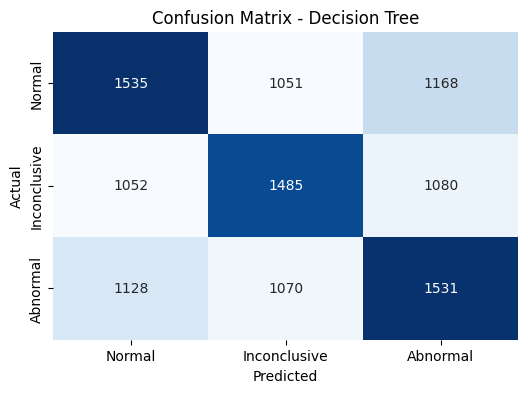

Training Random Forest...
Classification Report for Random Forest:
              precision    recall  f1-score   support

    Abnormal       0.43      0.43      0.43      3754
Inconclusive       0.43      0.44      0.44      3617
      Normal       0.44      0.43      0.44      3729

    accuracy                           0.43     11100
   macro avg       0.43      0.43      0.43     11100
weighted avg       0.43      0.43      0.43     11100

ROC-AUC Score: 0.6205782153329439



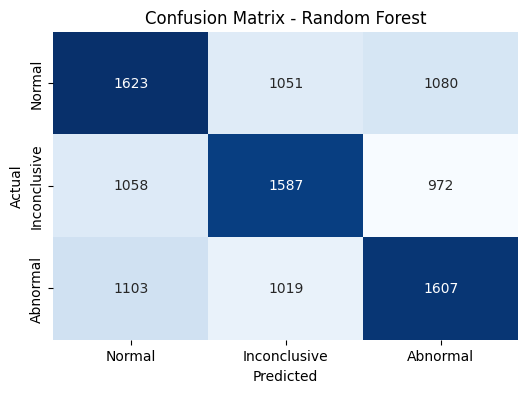

Training Gradient Boosting...
Classification Report for Gradient Boosting:
              precision    recall  f1-score   support

    Abnormal       0.34      0.41      0.37      3754
Inconclusive       0.33      0.28      0.30      3617
      Normal       0.34      0.32      0.33      3729

    accuracy                           0.34     11100
   macro avg       0.34      0.34      0.34     11100
weighted avg       0.34      0.34      0.34     11100

ROC-AUC Score: 0.5070455087808076



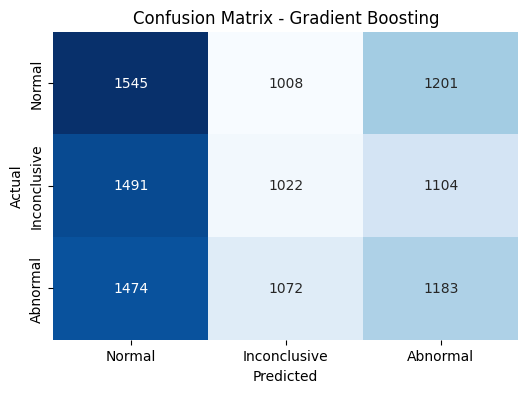

Training SVM...


In [ ]:


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=42)

# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=y.unique(), yticklabels=y.unique())
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Dictionary to store evaluation metrics
results = {}

# List of models to evaluate
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(random_state=42),
    'LightGBM': LGBMClassifier(random_state=42),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0),  # Set verbose=0 to suppress output
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Neural Network': MLPClassifier(random_state=42, max_iter=1000)
}

# Train and evaluate each model
for model_name, model in models.items():
    print(f"Training {model_name}...")

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)  # Probabilities for ROC-AUC

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')  # Use 'weighted' for multi-class
    recall = recall_score(y_test, y_pred, average='weighted')  # Use 'weighted' for multi-class
    f1 = f1_score(y_test, y_pred, average='weighted')  # Use 'weighted' for multi-class
    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')  # Use 'ovr' for multi-class

    # Store metrics in the results dictionary
    results[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

    # Print classification report
    print(f"Classification Report for {model_name}:")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC Score: {roc_auc}\n")

    # Plot confusion matrix
    plot_confusion_matrix(y_test, y_pred, model_name)

# Convert results dictionary to a DataFrame
results_df = pd.DataFrame(results).T
print("Model Evaluation Results:")
print(results_df)

In [ ]:
rersults_df